# Tratamento da Estação Centro

Este notebook organiza o tratamento horário da estação `Centro` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

A proposta aqui é fazer o básico bem feito, de forma rastreável e reutilizável para as próximas estações.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da estação

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da estação para evitar problemas de codificação e isolamos apenas os registros da estação `Centro`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_centro = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO CENTRO"].copy()

df_centro["data"] = pd.to_datetime(df_centro["data"])
df_centro = df_centro.sort_values("data").reset_index(drop=True)
df_centro = df_centro.drop_duplicates(subset="data", keep="first")
df_centro = df_centro.set_index("data").sort_index().copy()

print("Dimensoes da base da Estacao Centro:", df_centro.shape)
display(df_centro.head())

Dimensoes da base da Estacao Centro: (61368, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,ESTAÇÃO CENTRO,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.908344,-43.178152
2012-01-01 01:30:00,ESTAÇÃO CENTRO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.908344,-43.178152
2012-01-01 02:30:00,ESTAÇÃO CENTRO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.908344,-43.178152
2012-01-01 03:30:00,ESTAÇÃO CENTRO,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.908344,-43.178152
2012-01-01 04:30:00,ESTAÇÃO CENTRO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.908344,-43.178152


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_centro, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
no,61368,100.00,0
no2,61368,100.00,0
so2,61368,100.00,0
pm2_5,61368,100.00,0
nox,61368,100.00,0
ur,19759,32.20,41609
temp,19447,31.69,41921
o3,4668,7.61,56700
co,4331,7.06,57037
pm10,3697,6.02,57671


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_centro_tratado = df_centro.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_centro[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_centro_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"



    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_centro_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
7,o3,interpolate_time,4668,4271,397
8,co,interpolate_time,4331,3994,337
9,pm10,interpolate_time,3697,3361,336
6,temp,interpolate_time,19447,19328,119
5,ur,interpolate_time,19759,19642,117
0,no,interpolate_time,61368,61368,0
1,no2,interpolate_time,61368,61368,0
2,so2,interpolate_time,61368,61368,0
3,pm2_5,interpolate_time,61368,61368,0
4,nox,interpolate_time,61368,61368,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 1306


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
o3,4668,7.61,4271,6.96,397,8.50
co,4331,7.06,3994,6.51,337,7.78
pm10,3697,6.02,3361,5.48,336,9.09
temp,19447,31.69,19328,31.50,119,0.61
ur,19759,32.20,19642,32.01,117,0.59
no,61368,100.00,61368,100.00,0,0.00
no2,61368,100.00,61368,100.00,0,0.00
so2,61368,100.00,61368,100.00,0,0.00
nox,61368,100.00,61368,100.00,0,0.00
pm2_5,61368,100.00,61368,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
ur,67.681514,70.00,16.150619,67.695736,70.02,16.172495,0.014221,0.021876
temp,24.911583,24.35,4.383586,24.913294,24.35,4.383301,0.001710,-0.000285
o3,18.450520,12.68,18.920685,18.476143,12.74,18.906240,0.025623,-0.014444
co,0.407164,0.38,0.262056,0.407579,0.38,0.262044,0.000415,-0.000012
pm10,33.652858,30.00,23.022480,33.657610,30.00,22.989426,0.004752,-0.033054
chuva,0.114468,0.00,1.006809,0.114468,0.00,1.006809,0.000000,0.000000


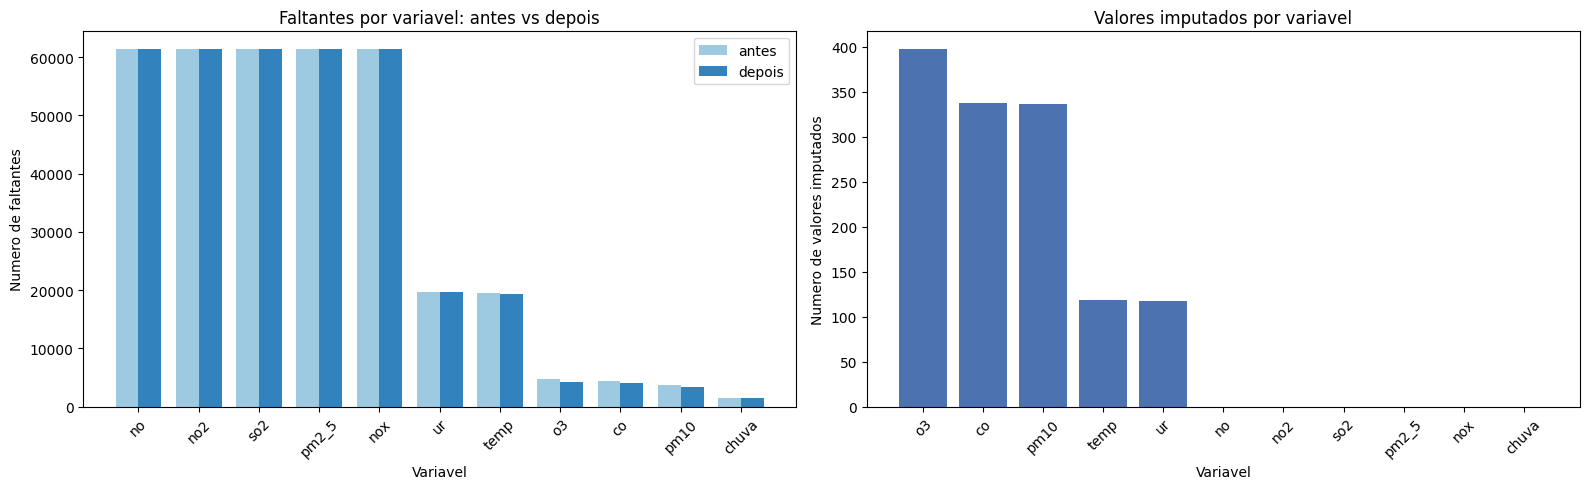

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_centro_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_centro[variavel].notna().any() or df_centro_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_centro, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_centro_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a Estação `Centro`:

- Série diária agregada (média para as variáveis e soma diária para `chuva`).

Essa saída já ficam prontas para reutilização nas próximas etapas da pipeline.


In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

# Saída diária agregada:
# - média para a maior parte das variáveis
# - soma para chuva (preservando NaN quando o dia inteiro está faltante)

def somar_chuva_diaria(serie: pd.Series) -> float:
    return serie.sum(min_count=1)

agregacoes_diarias = {
    variavel: "mean"
    for variavel in variaveis_ambientais
    if variavel != "chuva"
}
agregacoes_diarias["chuva"] = somar_chuva_diaria

df_centro_diario = (
    df_centro_tratado[variaveis_ambientais]
    .resample("D")
    .agg(agregacoes_diarias)
)

df_centro_diario_saida = df_centro_diario.reset_index()
output_csv_diario_path = output_dir / "centro_tratado_diario.csv"
df_centro_diario_saida.to_csv(output_csv_diario_path, index=False, encoding="utf-8")

print(f"Arquivo diario salvo em: {output_csv_diario_path}")
display(df_centro_diario_saida.head())


Arquivo diario salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\centro_tratado_diario.csv


,data,no,no2,so2,pm2_5,nox,ur,temp,o3,co,pm10,chuva
0,2012-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.6
1,2012-01-02,NaN,NaN,NaN,NaN,NaN,91.750000,20.155000,3.870000,0.165000,23.000000,47.6
2,2012-01-03,NaN,NaN,NaN,NaN,NaN,68.546250,23.614167,9.502917,0.322500,28.583333,0.2
3,2012-01-04,NaN,NaN,NaN,NaN,NaN,69.982083,24.027083,11.695000,0.314167,36.791667,0.0
4,2012-01-05,NaN,NaN,NaN,NaN,NaN,72.431667,24.650000,22.944583,0.339583,33.875000,0.0


## Resumo interpretativo do tratamento

O tratamento aplicado na estação `Centro` foi **conservador e com baixo impacto sobre o comportamento geral das séries**. Ao todo, foram imputados `1306` valores, com maior concentração em `o3` (`397`), `co` (`337`) e `pm10` (`336`). Em `temp` e `ur`, a redução de faltantes foi menor, o que sugere que parte importante das lacunas dessas variáveis ocorre em blocos mais longos do que a regra de até `4` horas permite preencher.

As variáveis `no`, `no2`, `so2`, `nox` e `pm2_5` permaneceram com ausência estrutural de dados e, por isso, não foram beneficiadas pelo tratamento. `chuva` também foi mantida sem interpolação, o que evita criar artificialmente eventos de precipitação. Isso mostra que a imputação curta ajuda a recuperar pequenas lacunas internas, mas não substitui variáveis que já chegam estruturalmente incompletas.

A comparação das estatísticas antes e depois indica mudanças muito pequenas em `media`, `mediana` e `desvio padrao` nas séries com dados observados. Em termos práticos, isso sugere que o tratamento aumentou moderadamente a completude sem distorcer de forma relevante a distribuição das variáveis, deixando a base mais consistente para as próximas etapas de consolidação e agregação temporal.